<a href="https://colab.research.google.com/github/roopaam/MB-Proxy/blob/main/Adult_DAG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Census Income Analysis


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(


  0%|          | 0/1000000 [00:00<?, ?it/s]


Discovered Bayesian Network:
age ---> marital-status
education ---> occupation
education ---> income
education-num ---> education
education-num ---> relationship
occupation ---> workclass
occupation ---> hours-per-week
relationship ---> marital-status
relationship ---> sex
relationship ---> age
relationship ---> hours-per-week
relationship ---> income
relationship ---> education
race ---> native-country
race ---> relationship
sex ---> occupation
sex ---> fnlwgt
hours-per-week ---> age
hours-per-week ---> workclass
native-country ---> education-num
income ---> age
income ---> sex


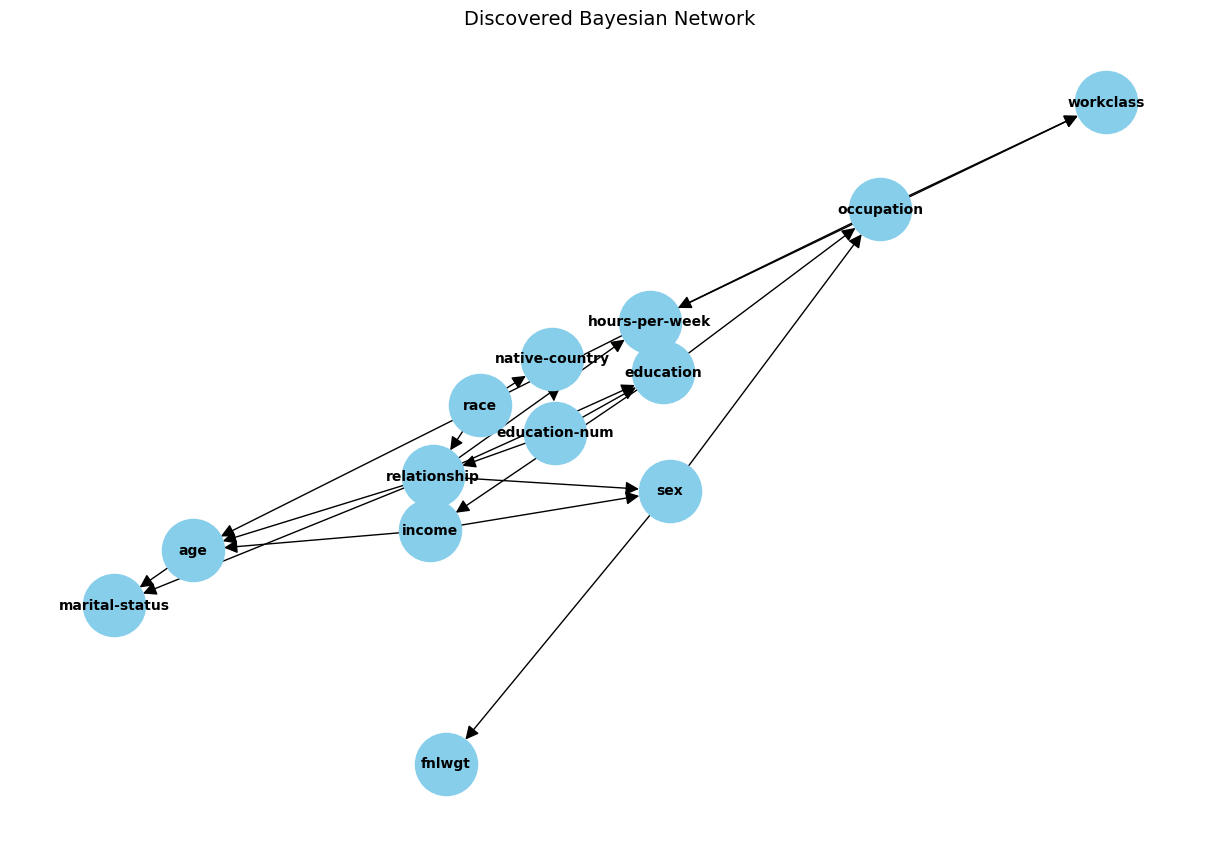

Markov Blanket for 'income' in Census dataset: ['relationship', 'age', 'sex', 'education', 'hours-per-week']
'marital-status' in Markov Blanket: False

COMPAS Analysis


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(


  0%|          | 0/1000000 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pgmpy/estimators/StructureScore.py:252: RuntimeWarning: overflow encountered in scalar multiply
  counts_size = num_parents_states * len(self.state_names[variable])
/usr/local/lib/python3.12/dist-packages/pgmpy/estimators/StructureScore.py:265: RuntimeWarning: overflow encountered in scalar multiply
  (num_parents_states - counts.shape[1])
/usr/local/lib/python3.12/dist-packages/pgmpy/estimators/StructureScore.py:252: RuntimeWarning: overflow encountered in scalar multiply
  counts_size = num_parents_states * len(self.state_names[variable])
/usr/local/lib/python3.12/dist-packages/pgmpy/estimators/StructureScore.py:265: RuntimeWarning: overflow encountered in scalar multiply
  (num_parents_states - counts.shape[1])
/usr/local/lib/python3.12/dist-packages/pgmpy/estimators/StructureScore.py:252: RuntimeWarning: overflow encountered in scalar multiply
  counts_size = num_parents_states * len(self.state_names[variable])
/usr/local/lib/python3.12/dist-


Discovered Bayesian Network:
id ---> name
id ---> dob
id ---> end
name ---> last
name ---> first
first ---> sex
first ---> last
last ---> dob
last ---> end
compas_screening_date ---> id
compas_screening_date ---> v_screening_date
dob ---> age
age ---> age_cat
age ---> r_jail_out
age ---> r_case_number
age ---> end
age_cat ---> v_decile_score
age_cat ---> priors_count.1
age_cat ---> juv_misd_count
priors_count ---> juv_misd_count
priors_count ---> juv_fel_count
days_b_screening_arrest ---> c_days_from_compas
days_b_screening_arrest ---> c_jail_in
days_b_screening_arrest ---> name
days_b_screening_arrest ---> end
c_jail_in ---> c_case_number
c_jail_in ---> out_custody
c_jail_in ---> in_custody
c_jail_in ---> dob
c_jail_in ---> end
c_jail_out ---> c_jail_in
c_jail_out ---> c_case_number
c_jail_out ---> dob
c_jail_out ---> name
c_case_number ---> id
c_offense_date ---> screening_date
c_offense_date ---> c_case_number
c_offense_date ---> id
c_arrest_date ---> screening_date
c_arrest_date -

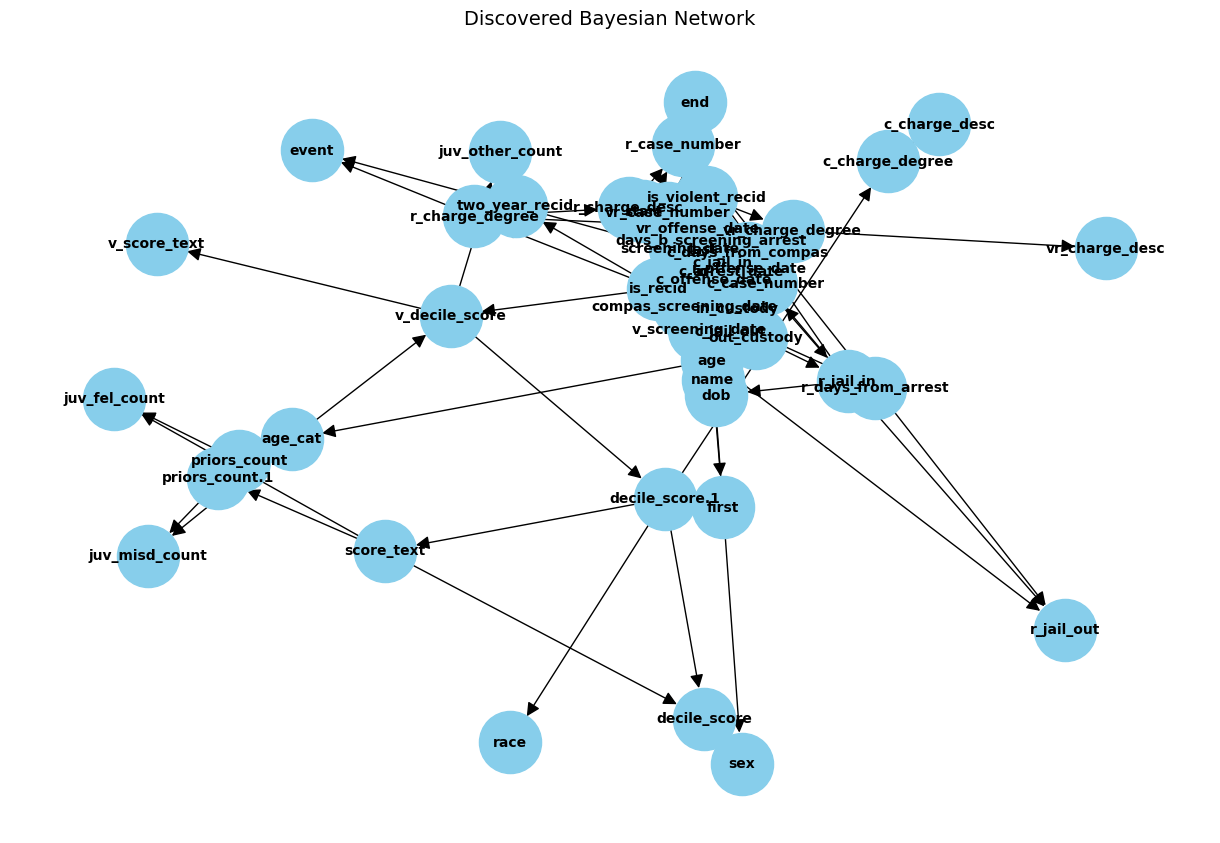

Markov Blanket for 'two_year_recid' in COMPAS dataset: ['c_jail_in', 'event', 'r_charge_degree', 'is_recid', 'c_jail_out', 'days_b_screening_arrest']
'priors_count' in Markov Blanket: False


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import KBinsDiscretizer, LabelEncoder
from pgmpy.estimators import HillClimbSearch, BDeu
from pgmpy.models import DiscreteBayesianNetwork
import networkx as nx
import matplotlib.pyplot as plt

# Preprocess data: discretize continuous columns and label-encode categorical variables
def preprocess_data(df, target, continuous_columns, categorical_columns):
    # Handle continuous columns with KBinsDiscretizer
    kbins = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='quantile')
    for col in continuous_columns:
        df[col] = kbins.fit_transform(df[col].values.reshape(-1, 1)).astype(int)

    # Label-encode categorical columns
    le = LabelEncoder()
    for col in categorical_columns:
        df[col] = le.fit_transform(df[col].astype(str))

    # Ensure the target column is also discretized
    if target in continuous_columns:
        df[target] = kbins.fit_transform(df[target].values.reshape(-1, 1)).astype(int)

    return df
def print_bayesian_network(edges, title="Bayesian Network"):
    """
    Prints and visualizes the Bayesian Network structure.

    Parameters:
        edges: list of tuples
            List of edges in the Bayesian Network.
        title: str
            Title of the visualization plot.
    """
    # Print the edges of the Bayesian Network
    print(f"\n{title}:")
    for edge in edges:
        print(f"{edge[0]} ---> {edge[1]}")

    # Visualize the network using matplotlib and networkx
    graph = nx.DiGraph()
    graph.add_edges_from(edges)
    plt.figure(figsize=(12, 8))
    nx.draw(graph, with_labels=True, node_size=2000, node_color="skyblue", font_size=10, font_weight="bold", arrowsize=20)
    plt.title(title, fontsize=14)
    plt.show()

# Function to learn Bayesian structure and find the Markov Blanket for a given target
def find_markov_blanket(df, target):
    try:
        hc = HillClimbSearch(df)
        model = hc.estimate(scoring_method=BDeu(df))
        edges = model.edges()
        bn = DiscreteBayesianNetwork(edges)
        # Print and visualize the Bayesian Network
        print_bayesian_network(edges, title="Discovered Bayesian Network")
        # Get and return the Markov Blanket
        markov_blanket = bn.get_markov_blanket(target)
        return markov_blanket
    except Exception as e:
        print(f"Error finding Markov Blanket for {target}: {e}")
        return None


# Analyze the UCI Census Income dataset
def analyze_census_income():
    census_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
    columns = [
        "age", "workclass", "fnlwgt", "education", "education-num", "marital-status",
        "occupation", "relationship", "race", "sex", "capital-gain", "capital-loss",
        "hours-per-week", "native-country", "income"
    ]
    df = pd.read_csv(census_url, header=None, names=columns, na_values=[" ?"])

    # Drop rows with missing values
    df.dropna(inplace=True)

    # Specify columns
    continuous_columns = ["age", "education-num", "capital-gain", "capital-loss", "hours-per-week"]
    categorical_columns = [col for col in df.columns if col not in continuous_columns + ["income"]]

    # Preprocess the data
    df = preprocess_data(df, "income", continuous_columns, categorical_columns)
    markov_blanket = find_markov_blanket(df, "income")

    # Output results
    if markov_blanket is not None:
        print("Markov Blanket for 'income' in Census dataset:", markov_blanket)
        print("'marital-status' in Markov Blanket:", "marital-status" in markov_blanket)
    else:
        print("Could not find Markov Blanket for the Census dataset.")

# Analyze the ProPublica COMPAS dataset
def analyze_compas():
    compas_url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
    df = pd.read_csv(compas_url)

    # Specify target and columns
    target = "two_year_recid"
    continuous_columns = ["priors_count"]
    categorical_columns = [col for col in df.columns if col not in continuous_columns + [target]]

    # Drop rows with missing values
    #df.dropna(inplace=True)

    # Preprocess the data
    df = preprocess_data(df, target, continuous_columns, categorical_columns)
    markov_blanket = find_markov_blanket(df, target)

    # Output results
    if markov_blanket is not None:
        print("Markov Blanket for 'two_year_recid' in COMPAS dataset:", markov_blanket)
        print("'priors_count' in Markov Blanket:", "priors_count" in markov_blanket)
    else:
        print("Could not find Markov Blanket for the COMPAS dataset.")

if __name__ == "__main__":
    print("Census Income Analysis")
    analyze_census_income()
    print("\nCOMPAS Analysis")
    analyze_compas()